# Curva dei Treasury USA: Nelson-Siegel e valore relativo

Questo notebook ripercorre il progetto in ordine: matematica obbligazionaria, curva, mondo sintetico,
dati reali, strategia. Le tabelle sono prodotte dal codice del pacchetto; il testo spiega cosa guardare.
Tassi in percentuale, differenze in punti base (bp).

In [1]:
import sys
from pathlib import Path
from datetime import date

RADICE = Path.cwd().parent
sys.path.insert(0, str(RADICE / "src"))

import numpy as np
import pandas as pd
from io import BytesIO

import matplotlib.pyplot as plt
from IPython.display import Image, display

from yield_curve_relative_value import analisi as an
from yield_curve_relative_value import dati, grafici
from yield_curve_relative_value import curva as cv
from yield_curve_relative_value import obbligazioni as ob
from yield_curve_relative_value import strategia as sg

pd.set_option("display.width", 150)


def mostra(fig):
    # mostra il grafico come immagine PNG incorporata nel notebook
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buf.getvalue()))


cmt, gsw = dati.carica_storico()
par_t = dati.par_cmt(cmt).dropna(how="all")
par_f = dati.par_gsw(gsw)
print(f"Tesoro: {len(par_t)} giorni dal {par_t.index[0].date()} al {par_t.index[-1].date()}")

Tesoro: 6502 giorni dal 2000-01-03 al 2025-12-31


## 1. Matematica di un titolo

Un titolo a cedola semestrale: prezzo sporco dato il rendimento, rateo ACT/ACT, prezzo pulito, e le misure
di sensibilita'. Qui un esempio con date fisse; il rendimento e' ricalcolato dal prezzo come controllo.

In [2]:
reg, scad, cedola, y = date(2025, 6, 30), date(2035, 5, 15), 4.25, 4.40
sporco = ob.prezzo_sporco(y, cedola, scad, reg)
esempio = pd.Series({
    "prezzo sporco": sporco,
    "rateo": ob.rateo(cedola, scad, reg),
    "prezzo pulito": ob.prezzo_pulito(y, cedola, scad, reg),
    "rendimento ricalcolato": ob.rendimento(ob.prezzo_pulito(y, cedola, scad, reg), cedola, scad, reg),
    "duration modificata": ob.duration_modificata(y, cedola, scad, reg),
    "DV01 (per 100)": ob.dv01(y, cedola, scad, reg),
    "convessita'": ob.convessita(y, cedola, scad, reg),
})
display(esempio.round(4).to_frame("valore"))

,valore
prezzo sporco,99.3359
rateo,0.5312
prezzo pulito,98.8047
rendimento ricalcolato,4.4000
duration modificata,7.9372
DV01 (per 100),0.0788
convessita',75.2528


## 2. La curva e il controllo contro la Fed

La formula di Svensson con i parametri pubblicati dalla Fed deve riprodurre zero, forward e par yield che la
Fed pubblica. Qui un campione di 40 date dal 1971 (stesso file usato dai test). Lo scarto massimo e' in punti
percentuali; la Fed arrotonda a 4 decimali.

In [3]:
camp = pd.read_csv(RADICE / "tests" / "dati" / "gsw_campione.csv", index_col=0, parse_dates=True)
n = np.arange(1, 31)
scarti = {"zero": 0.0, "forward": 0.0, "par yield": 0.0}
for _, r in camp.iterrows():
    p = cv.Parametri(r.BETA0, r.BETA1, r.BETA2, r.BETA3, r.TAU1, r.TAU2 if r.BETA3 != 0 else 5.0)
    for nome, pref, calc in (("zero", "SVENY", cv.rendimento_zero(n, p)), ("forward", "SVENF", cv.forward(n, p)),
                             ("par yield", "SVENPY", np.array([cv.par_yield(k, p) for k in n]))):
        pub = np.array([r[f"{pref}{k:02d}"] for k in n])
        scarti[nome] = max(scarti[nome], float(np.nanmax(np.abs(calc - pub))))
display(pd.Series(scarti).to_frame("scarto massimo (punti %)"))

,scarto massimo (punti %)
zero,0.00005
forward,0.00005
par yield,0.00005


## 3. Mondo sintetico

Prima dei dati veri: una curva Nelson-Siegel nota, con mispricing e rumore noti. Serve a sapere quanto deve
essere grande un mispricing per essere distinguibile dal rumore, e a vedere i falsi positivi. Le tabelle
vengono da `scripts/esegui_sintetico.py`.

In [4]:
for nome in ("recupero", "falsi_positivi", "arrotondamento", "potere", "potere_arrotondato"):
    f = RADICE / "output" / f"sintetico_{nome}.csv"
    if f.exists():
        print(nome)
        display(pd.read_csv(f, index_col=0))
    else:
        print(f"{f.name} non trovato: esegui scripts/esegui_sintetico.py")

recupero


,rmse_beta0,rmse_beta1,rmse_beta2,rmse_tau,rmse_curva_bp
tau libero,0.012,0.027,0.411,0.648,0.363
tau fisso = vero (2.0),0.005,0.009,0.027,0.000,0.306
tau fisso Diebold-Li (1.37),0.057,0.302,0.910,0.630,2.331


falsi_positivi


,curva vera,fit,costo (bp),frequenza t>2,guadagno medio (bp/giorno)
0,ns,tau libero,0.00,0.983,0.0114
1,ns,tau libero,0.25,0.000,-0.1185
2,ns,tau fisso 2.0,0.00,0.017,-0.0003
3,ns,tau fisso 2.0,0.25,0.000,-0.1311
4,svensson,tau libero,0.00,1.000,0.0778
5,svensson,tau libero,0.25,0.000,-0.0212
6,svensson,tau fisso 2.0,0.00,0.117,0.0027
7,svensson,tau fisso 2.0,0.25,0.000,-0.0903


arrotondamento


,fit,arrotondamento (bp),falsi positivi (costo 0),falsi positivi (costo 0.25),potere a 1.75 bp (costo 0.25)
0,tau libero,0.0,0.983,0.0,0.90
1,tau libero,1.0,0.933,0.0,0.46
2,tau fisso 2.0,0.0,0.017,0.0,0.72
3,tau fisso 2.0,1.0,0.033,0.0,0.15


potere


,"libero, stesso giorno, costo 0.0","libero, stesso giorno, costo 0.25","libero, stesso giorno, costo 0.5","tau fisso, stesso giorno, costo 0.0","tau fisso, stesso giorno, costo 0.25","tau fisso, stesso giorno, costo 0.5","tau fisso, giorno dopo, costo 0.0","tau fisso, giorno dopo, costo 0.25","tau fisso, giorno dopo, costo 0.5"
mispricing dev.std (bp),,,,,,,,,
0.10,0.98,0.00,0.00,0.11,0.00,0.00,0.09,0.00,0.00
0.25,1.00,0.00,0.00,0.94,0.00,0.00,0.90,0.00,0.00
0.50,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
1.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
1.50,1.00,0.03,0.00,1.00,0.00,0.00,1.00,0.00,0.00
1.75,1.00,0.90,0.00,1.00,0.72,0.00,1.00,0.01,0.00
2.00,1.00,1.00,0.00,1.00,1.00,0.00,1.00,0.68,0.00
2.50,1.00,1.00,0.00,1.00,1.00,0.00,1.00,1.00,0.00
3.00,1.00,1.00,0.55,1.00,1.00,0.82,1.00,1.00,0.00


potere_arrotondato


,"libero, stesso giorno, costo 0.0","libero, stesso giorno, costo 0.25","libero, stesso giorno, costo 0.5","tau fisso, stesso giorno, costo 0.0","tau fisso, stesso giorno, costo 0.25","tau fisso, stesso giorno, costo 0.5","tau fisso, giorno dopo, costo 0.0","tau fisso, giorno dopo, costo 0.25","tau fisso, giorno dopo, costo 0.5"
mispricing dev.std (bp),,,,,,,,,
0.10,0.88,0.00,0.00,0.05,0.00,0.00,0.06,0.00,0.00
0.25,1.00,0.00,0.00,0.78,0.00,0.00,0.69,0.00,0.00
0.50,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
1.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
1.50,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
1.75,1.00,0.46,0.00,1.00,0.15,0.00,1.00,0.00,0.00
2.00,1.00,1.00,0.00,1.00,1.00,0.00,1.00,0.33,0.00
2.50,1.00,1.00,0.00,1.00,1.00,0.00,1.00,1.00,0.00
3.00,1.00,1.00,0.23,1.00,1.00,0.51,1.00,1.00,0.00


## 4. Premio del titolo nuovo: Tesoro meno Fed

I punti del Tesoro sono costruiti con i soli titoli appena emessi; la curva della Fed li esclude. La differenza
misura quanto costano di piu' i titoli nuovi (segno negativo = rendimento piu' basso). Il Tesoro ha cambiato
metodo di costruzione il 6 dicembre 2021, quindi i periodi si leggono separati. Il t e' di Newey-West con 250
ritardi, perche' le serie sono molto persistenti.

media  mediana  dev_std  t_NW  giorni
periodo         scadenza                                       
fino a dic 2021 1         -3.62    -2.77     7.25 -3.16    5485
                2         -0.83    -0.93     3.62 -1.55    5485
                3         -1.82    -1.84     4.11 -2.92    5485
                5         -1.95    -1.67     3.32 -3.85    5485
                7         -2.60    -0.69     6.30 -2.37    5485
                10       -10.86    -6.97    11.00 -5.02    5485
                20        -5.87    -5.29     5.32 -5.68    5485
                30        -3.10    -2.06     7.79 -1.99    4491
da dic 2021     1         -1.71    -1.72     4.98 -1.51    1017
                2         -3.53    -2.72     2.74 -4.91    1017
                3         -2.89    -2.52     2.28 -4.47    1017
                5         -2.46    -2.20     1.61 -5.37    1017
                7          0.22     0.10     1.80  0.96    1017
                10        -5.66    -5.25     3.01 -6.42    1017
                20         4.99     4.37     3.05  4.95    1017
                30       -11.59   -10.48     6.29 -5.33    1017

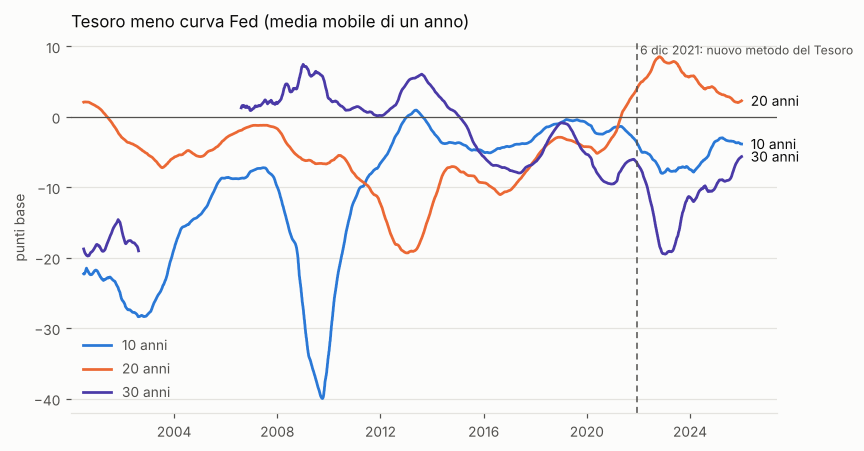

In [5]:
premio = an.differenza_bp(par_t, par_f)
display(an.riepilogo(premio).drop(index="intero", level=0))
mostra(grafici.grafico_premio(premio))

## 5. Nelson-Siegel sui punti del Tesoro

La curva si adatta ogni giorno ai par yield (non ai tassi zero) e il residuo e' il valore osservato meno la
curva. Se i residui fossero rumore non dovrebbero avere memoria: sotto si vede la loro autocorrelazione a un
giorno.

In [6]:
f = RADICE / "output" / "ns_residui_bp.csv"
if f.exists():
    residui = pd.read_csv(f, index_col=0, parse_dates=True)
    residui.columns = [int(c) for c in residui.columns]
else:
    residui = an.adatta_serie(par_t)[1]
rmse = pd.DataFrame({k: np.sqrt((v ** 2).mean()) for k, v in an.periodi(residui).items()}).T.round(2)
display(rmse)
display(pd.DataFrame({"autocorrelazione a 1 giorno": {c: residui[c].autocorr(1) for c in residui.columns}}).T.round(2))

,1,2,3,5,7,10,20,30
fino a dic 2021,2.54,3.19,2.48,3.04,3.79,5.61,8.12,6.31
da dic 2021,1.99,2.56,3.23,1.71,2.33,7.17,12.04,6.96
intero,2.46,3.10,2.61,2.87,3.60,5.88,8.85,6.43


,1,2,3,5,7,10,20,30
autocorrelazione a 1 giorno,0.91,0.93,0.92,0.96,0.97,0.98,0.99,0.99


## 6. Componenti principali contro fattori, e previsione

Le tre componenti principali delle variazioni giornaliere contro i tre fattori di Nelson-Siegel (livello,
pendenza, curvatura con il tau di Diebold-Li). Poi la previsione fuori campione dei fattori: AR(1) contro
passeggiata casuale.

In [7]:
completi = par_t.dropna()
# le variazioni si calcolano con i buchi (30 anni assenti 2002-2006) e poi si scartano: niente "giorno" di 4 anni
var, punteggi, _ = an.pca(par_t.diff().dropna() * 100)
fattori = an.fattori_dl(completi).diff()
fattori = fattori[par_t.diff().notna().all(axis=1).reindex(fattori.index).fillna(False)]
display(pd.DataFrame({"varianza spiegata": var.round(3), "R2 sui 3 fattori": an.r2_su_fattori(punteggi, fattori).round(3).to_numpy()},
                     index=["PC1", "PC2", "PC3"]))
righe = []
for h in (1, 6, 12):
    rm, dm, k, cw = an.previsione_dl(completi, h, "2010-01-01")
    righe.append({"orizzonte (mesi)": h, "previsioni": k, "RMSE AR(1)": rm["AR(1)"].mean().round(1),
                  "RMSE passeggiata casuale": rm["RW"].mean().round(1), "t Diebold-Mariano": dm,
                  "t Clark-West": cw})
display(pd.DataFrame(righe).set_index("orizzonte (mesi)"))

,varianza spiegata,R2 sui 3 fattori
PC1,0.843,1.000
PC2,0.112,1.000
PC3,0.024,0.996


,previsioni,RMSE AR(1),RMSE passeggiata casuale,t Diebold-Mariano,t Clark-West
orizzonte (mesi),,,,,
1,191,24.2,23.3,-2.32,-0.68
6,186,70.2,62.9,-1.91,-0.29
12,180,111.4,96.8,-1.60,-0.05


## 7. Farfalle

Regola: z-score su 60 giorni precedenti, soglia 1, posizione sul rientro. Farfalla 2-5-10 con pesi DV01
(0.5, -1, 0.5) e neutrale ai fattori, con tre livelli di costo per gamba e due modi di eseguire: allo stesso
prezzo che genera il segnale, oppure il giorno dopo. Il guadagno e' in bp per unita' di DV01 al giorno.

bp/giorno
neutralita esecuzione    costo (bp)           
dv01       stesso giorno 0.00           0.0718
                         0.25          -0.0201
                         0.50          -0.1120
           giorno dopo   0.00           0.0311
                         0.25          -0.0608
                         0.50          -0.1528
fattori    stesso giorno 0.00           0.0641
                         0.25          -0.0237
                         0.50          -0.1115
           giorno dopo   0.00           0.0368
                         0.25          -0.0510
                         0.50          -0.1388

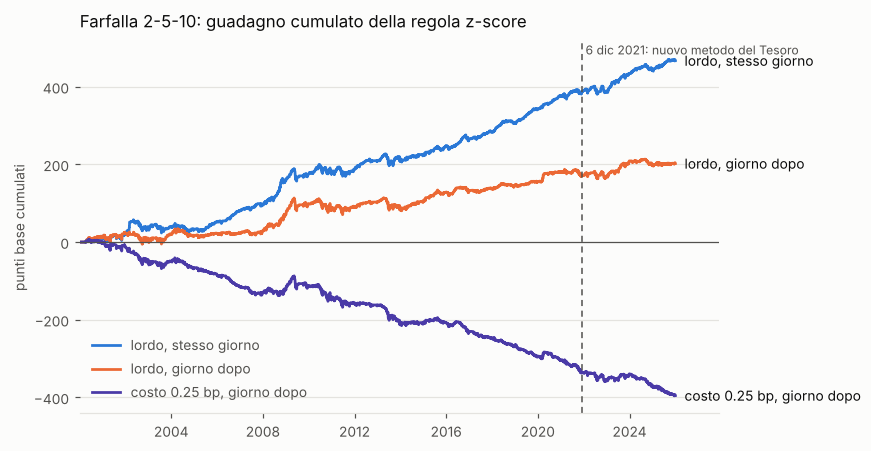

In [8]:
righe = []
cum = None
for neutr in ("dv01", "fattori"):
    w = sg.pesi_farfalla((2, 5, 10), neutr)
    x = sg.serie_farfalla(par_t, (2, 5, 10), w)
    for ritardo in (0, 1):
        for costo in (0.0, 0.25, 0.5):
            g, _ = sg.guadagni_serie(x.to_numpy(), x.to_numpy(), abs(w).sum(), 60, 1.0, costo, ritardo=ritardo)
            righe.append({"neutralita": neutr, "esecuzione": "giorno dopo" if ritardo else "stesso giorno",
                          "costo (bp)": costo, "bp/giorno": g.mean().round(4)})
    if neutr == "dv01":
        cum = grafici.guadagni_cumulati(x, abs(w).sum())
display(pd.DataFrame(righe).set_index(["neutralita", "esecuzione", "costo (bp)"]))
mostra(grafici.grafico_guadagni(cum, "Farfalla 2-5-10: guadagno cumulato della regola z-score"))

## 8. La curva di oggi

Il confronto fra l'ultimo giorno disponibile e lo storico non e' nel notebook, perche' dipende dal giorno in cui
si esegue: lo produce `python scripts/analisi_corrente.py`, che scarica i dati recenti in `data/corrente/`
(cartella non versionata) e stampa residui, z-score e farfalle.

## Conclusioni

- Il residuo di Nelson-Siegel sui punti del Tesoro e' molto persistente. Un residuo stazionario e persistente
  guadagna con questa regola anche senza alcun mispricing: il guadagno lordo reale va confrontato con quello,
  non con zero (tabella nel README, sezione 9).
- Con lo scambio il giorno dopo il segnale, il guadagno lordo cala molto e con un costo di 0.25 bp diventa
  negativo per tutte le strategie provate.
- Il premio del titolo nuovo e' negativo quasi ovunque, ma cambia nel tempo e in alcune scadenze e' poco
  distinguibile da zero con errori standard prudenti.

I limiti (punti interpolati, nessun prezzo eseguibile, costi ipotizzati) sono nel README.